In [1]:
import os, random, time, traceback, sys
from pathlib import Path
import numpy as np
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit

import joblib

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Reproducibility
RND = 42
random.seed(RND)
np.random.seed(RND)
torch.manual_seed(RND)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RND)


Device: cpu


In [2]:
# Update these paths if needed (these are the paths you provided)
TRAIN_HEALTHY = "/Users/mohak.verma/Desktop/Code/dataset/spiral/training/healthy"
TRAIN_PARK    = "/Users/mohak.verma/Desktop/Code/dataset/spiral/training/parkinson"
TEST_HEALTHY  = "/Users/mohak.verma/Desktop/Code/dataset/spiral/testing/healthy"
TEST_PARK     = "/Users/mohak.verma/Desktop/Code/dataset/spiral/testing/parkinson"

def list_images(folder):
    p = Path(folder)
    if not p.exists():
        return []
    exts = {'.png','.jpg','.jpeg','.bmp','.tif','.tiff'}
    return sorted([str(x) for x in p.iterdir() if x.suffix.lower() in exts])

train_h = list_images(TRAIN_HEALTHY)
train_p = list_images(TRAIN_PARK)
test_h  = list_images(TEST_HEALTHY)
test_p  = list_images(TEST_PARK)

print("Found images:")
print("  train healthy:", len(train_h))
print("  train parkinson:", len(train_p))
print("  test healthy:", len(test_h))
print("  test parkinson:", len(test_p))

all_train_files = train_h + train_p
all_train_labels = [0]*len(train_h) + [1]*len(train_p)
all_test_files  = test_h + test_p
all_test_labels = [0]*len(test_h) + [1]*len(test_p)


Found images:
  train healthy: 36
  train parkinson: 36
  test healthy: 15
  test parkinson: 15


In [3]:
# Optional scan to list images PIL can't verify/read. Run and inspect output.
from PIL import Image
bad_files = []
for fp in all_train_files + all_test_files:
    try:
        im = Image.open(fp)
        im.verify()
    except Exception as e:
        bad_files.append(fp)
        print("Unreadable:", fp, "->", repr(e))
print("Scan complete. Bad files found:", len(bad_files))
# If you find bad files, open and re-save them or remove them before running training.


Scan complete. Bad files found: 0


In [4]:
# Use lighter augmentations (no RandomResizedCrop). These are safer for spirals.
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=10),           # small rotation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class SafeSpiralDataset(Dataset):
    """Dataset that safely loads images and returns dummy if an image fails to load."""
    def __init__(self, filepaths, labels, transform=None):
        assert len(filepaths) == len(labels)
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        fp = self.filepaths[idx]
        label = int(self.labels[idx])
        try:
            img = Image.open(fp).convert("RGB")
            if self.transform:
                img = self.transform(img)
            return img, label
        except Exception as e:
            # Log and return dummy tensor (white image) so loader doesn't crash
            print(f"[SafeSpiralDataset] Warning: failed to load {fp}. Error: {e}", file=sys.stderr)
            traceback.print_exc()
            dummy = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (255,255,255))
            if self.transform:
                dummy_t = self.transform(dummy)
            else:
                dummy_t = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
            return dummy_t, label


In [5]:
# We will split the provided training set into train and validation (stratified)
test_size_val = 0.2   # 20% of training set becomes validation
sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size_val, random_state=RND)
train_idx, val_idx = next(sss.split(all_train_files, all_train_labels))

train_files = [all_train_files[i] for i in train_idx]
train_labels = [all_train_labels[i] for i in train_idx]
val_files = [all_train_files[i] for i in val_idx]
val_labels = [all_train_labels[i] for i in val_idx]

print("After split -> train:", len(train_files), "val:", len(val_files))
# quick class distribution
import collections
print("Train class counts:", collections.Counter(train_labels))
print("Val class counts:", collections.Counter(val_labels))


After split -> train: 57 val: 15
Train class counts: Counter({1: 29, 0: 28})
Val class counts: Counter({0: 8, 1: 7})


In [6]:
# Create dataset objects
train_ds = SafeSpiralDataset(train_files, train_labels, transform=train_transform)
val_ds   = SafeSpiralDataset(val_files, val_labels, transform=val_test_transform)
test_ds  = SafeSpiralDataset(all_test_files, all_test_labels, transform=val_test_transform)

# WeightedRandomSampler to balance classes during training
from collections import Counter
train_counts = Counter(train_labels)
print("train_counts:", train_counts)
class_sample_count = np.array([train_counts.get(i,0) for i in sorted(train_counts.keys())])
# compute weights: inversely proportional to class count
class_weights = {cls: 1.0/count for cls, count in train_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoader params (start with num_workers=0)
BATCH_SIZE = 8
NUM_WORKERS = 0   # set to 0 for notebook/Windows; increase to 2-4 if stable
PIN_MEMORY = True if DEVICE == "cuda" else False

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# Quick sanity: fetch one batch
xb, yb = next(iter(train_loader))
print("One batch - xb.shape:", xb.shape, "yb.shape:", yb.shape)


train_counts: Counter({1: 29, 0: 28})
One batch - xb.shape: torch.Size([8, 3, 224, 224]) yb.shape: torch.Size([8])


In [7]:
def make_resnet18_finetune(pretrained=True, freeze_until_layer='layer4'):
    model = models.resnet18(pretrained=pretrained)
    # Freeze all layers first
    for name, param in model.named_parameters():
        param.requires_grad = False
    # Unfreeze layer4 and fc
    for name, param in model.named_parameters():
        if name.startswith(freeze_until_layer) or name.startswith('fc'):
            param.requires_grad = True
    # Replace final fc
    in_f = model.fc.in_features
    model.fc = nn.Linear(in_f, 2)
    return model

model = make_resnet18_finetune(pretrained=True, freeze_until_layer='layer4').to(DEVICE)
# Print trainable params summary
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable} / {total}")


Trainable params: 8394754 / 11177538


/Users/mohak.verma/.pyenv/versions/3.12.13/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mohak.verma/.pyenv/versions/3.12.13/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
criterion = nn.CrossEntropyLoss()
LR = 1e-4
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)

# Reduce LR on plateau (compatible)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# Early stopping settings
PATIENCE = 6    # stop if no improvement in validation AUC for this many epochs
best_val_auc = -np.inf
best_state = None
epochs_no_improve = 0
MAX_EPOCHS = 30

from tqdm.auto import tqdm

def evaluate_on_loader(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(yb.cpu().numpy().tolist())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)



/Users/mohak.verma/.pyenv/versions/3.12.13/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
start_time = time.time()
for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS}", leave=False)
    for xb, yb in loop:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
        loop.set_postfix(loss=running_loss/total, acc=correct/total)
    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    y_val_true, y_val_pred, y_val_prob = evaluate_on_loader(model, val_loader, DEVICE)
    try:
        val_auc = roc_auc_score(y_val_true, y_val_prob)
    except:
        val_auc = float('nan')
    val_acc = accuracy_score(y_val_true, y_val_pred)

    # Scheduler step (monitor validation AUC if available, else val_acc)
    monitor = val_auc if not np.isnan(val_auc) else val_acc
    scheduler.step(monitor)

    print(f"Epoch {epoch} summary: train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f} val_auc={val_auc:.4f}")

    # Early stopping by val_auc
    if not np.isnan(val_auc):
        if val_auc > best_val_auc + 1e-4:  # improvement
            best_val_auc = val_auc
            best_state = model.state_dict().copy()
            epochs_no_improve = 0
            print(f"  New best val_auc: {best_val_auc:.4f} (saving state)")
        else:
            epochs_no_improve += 1
            print(f"  No improvement in val_auc for {epochs_no_improve} epochs")
    else:
        # fallback to using val_acc
        if val_acc > (best_val_auc if not np.isnan(best_val_auc) else 0):
            best_state = model.state_dict().copy()
            epochs_no_improve = 0
            best_val_auc = val_acc
            print(f"  New best val_acc: {val_acc:.4f} (saving state)")
        else:
            epochs_no_improve += 1
            print(f"  No improvement in val_acc for {epochs_no_improve} epochs")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping after {epoch} epochs (no improvement for {PATIENCE} epochs).")
        break

# load best state
if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model from training with val metric:", best_val_auc)
print("Training complete in {:.1f} minutes".format((time.time()-start_time)/60))


Epoch 1 summary: train_loss=0.5520 train_acc=0.7018 val_acc=0.8667 val_auc=1.0000
  New best val_auc: 1.0000 (saving state)


Epoch 2 summary: train_loss=0.3962 train_acc=0.8070 val_acc=0.9333 val_auc=0.9821
  No improvement in val_auc for 1 epochs


Epoch 3 summary: train_loss=0.2730 train_acc=0.8947 val_acc=0.8667 val_auc=0.9821
  No improvement in val_auc for 2 epochs


Epoch 4 summary: train_loss=0.2258 train_acc=0.8947 val_acc=0.9333 val_auc=0.9821
  No improvement in val_auc for 3 epochs


Epoch 5 summary: train_loss=0.2170 train_acc=0.8772 val_acc=0.9333 val_auc=0.9821
  No improvement in val_auc for 4 epochs


Epoch 6 summary: train_loss=0.3759 train_acc=0.8246 val_acc=0.9333 val_auc=1.0000
  No improvement in val_auc for 5 epochs


Epoch 7 summary: train_loss=0.1580 train_acc=0.9298 val_acc=0.9333 val_auc=1.0000
  No improvement in val_auc for 6 epochs
Early stopping after 7 epochs (no improvement for 6 epochs).
Loaded best model from training with val metric: 1.0
Training complete in 0.1 minutes


Final test accuracy: 0.9

Classification report:

              precision    recall  f1-score   support

     healthy     0.9286    0.8667    0.8966        15
   parkinson     0.8750    0.9333    0.9032        15

    accuracy                         0.9000        30
   macro avg     0.9018    0.9000    0.8999        30
weighted avg     0.9018    0.9000    0.8999        30



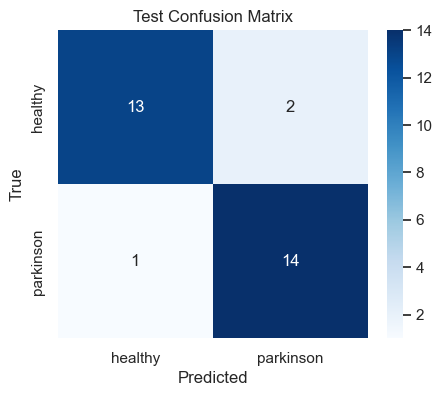

Test ROC AUC: 0.92


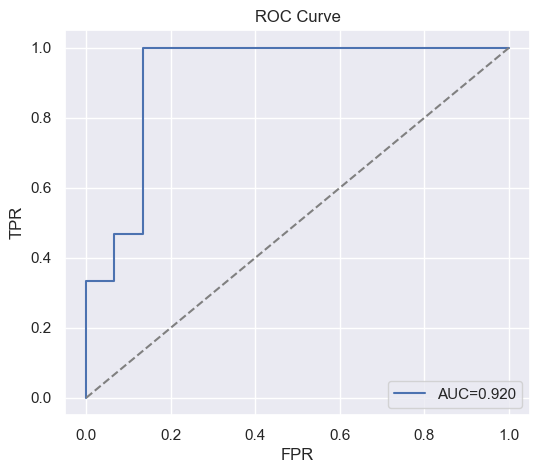

Saved model and metadata to /Users/mohak.verma/Desktop/Code/parkinson_detection/resnet18_improved


In [10]:
# Evaluate on test set
y_test_true, y_test_pred, y_test_prob = evaluate_on_loader(model, test_loader, DEVICE)
test_acc = accuracy_score(y_test_true, y_test_pred)
print("Final test accuracy:", test_acc)
print("\nClassification report:\n")
print(classification_report(y_test_true, y_test_pred, target_names=["healthy","parkinson"], digits=4))

cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["healthy","parkinson"], yticklabels=["healthy","parkinson"])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Test Confusion Matrix")
plt.show()

# ROC
try:
    test_auc = roc_auc_score(y_test_true, y_test_prob)
    print("Test ROC AUC:", test_auc)
    fpr, tpr, _ = roc_curve(y_test_true, y_test_prob)
    plt.figure(figsize=(6,5)); plt.plot(fpr,tpr,label=f"AUC={test_auc:.3f}"); plt.plot([0,1],[0,1],'--',color='gray'); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend(); plt.show()
except Exception as e:
    print("Could not compute ROC AUC:", e)

# Save model weights and metadata
out_dir = Path("resnet18_improved")
out_dir.mkdir(exist_ok=True)
torch.save(model.state_dict(), out_dir / "resnet18_improved_spiral.pth")
joblib.dump({"image_size": IMAGE_SIZE, "mean":[0.485,0.456,0.406], "std":[0.229,0.224,0.225]}, out_dir / "metadata.joblib")
print("Saved model and metadata to", out_dir.resolve())
